In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror{font-family:Consolas; font-size:15pt;}
div.output{font-size:12pt; font-weight:bold;}
div.input{font-family:Consolas; font-size:12pt;}
div.prompt{min-width:70px;}
div#toc-wrapper {padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# <span style="color:red">ch09. Transformers</span>
- 인코더 층만으로 구현(입력:자연어, 출력:긍정/부정)

## 1. 패키지

In [2]:
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, GRU
from time import time # 70.1.1부터 현재까지의 밀리세컨

from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

## 2. 하이퍼 파라미터 설정(이 파라미터를 바꾸면 정확도나 학습 속도에 차이남)

In [3]:
MY_WORDS = 10000 # imdb 데이터의 단어수
MY_LENGTH = 80   # 영화평 단어수 80개만 독립변수
MY_EMBED = 32    # Emdedding layer의 결과 차원
MY_HIDDEN = 64   # LSTM의 units 차원

MY_EPOCH = 10    # 학습 수(fit)
MY_BATCH = 200   # batch_size(fit시 매번 데이터를 가져오는 데이터)

## 3. 데이터 불러오기

In [4]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=MY_WORDS)

## 4. 문자단어 -> 정수

In [7]:
word_to_id = imdb.get_word_index() # {'word':id}
# 정수 -> 문자 단어
id_to_word = {} # {1:'the', 3:'a'} : 숫자에 맞는 단어를 찾을 수 있음
for word, value in word_to_id.items():
    id_to_word[value] = word
print(id_to_word[1])
print(id_to_word[3])

the
a


## 5. 숫자영화평 -> 자연어 영화평 return 함수

In [8]:
def decoding(review_num):
    decoded = [id_to_word.get(num-3, '???') for num in review_num]
    return ' '.join(decoded)

In [10]:
print(decoding(x_train[1]), y_train[1])

??? big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love cheesy horror movies and i've seen hundreds but this had got to be on of the worst ever made the plot is paper thin and ridiculous the acting is an abomination the script is completely laughable the best is the end showdown with the cop and how he worked out who the killer is it's just so damn terribly written the clothes are sickening and funny in equal ??? the hair is big lots of boobs ??? men wear those cut ??? shirts that show off their ??? sickening that men actually wore them and the music is just ??? trash that plays over and over again in almost every scene there is trashy music boobs and ??? taking away bodies and the gym still doesn't close for ??? all joking aside this is a truly bad film whose only charm is to look back on the disaster that was the 80's and have a good old laugh at how bad everything was back then 0


## 6. 영화평 (입력변수)의 길이

In [9]:
def show_length(x_train):
    print('첫 20개 영화평 길이')
    print([len(x_data) for x_data in x_train[:20]])

In [12]:
# pad_sequence 전
show_length(x_train)

첫 20개 영화평 길이
[218, 189, 141, 550, 147, 43, 123, 562, 233, 130, 450, 99, 117, 238, 109, 129, 163, 752, 212, 177]


## 7. 모든 영화평 길이를 동일하게(MY_LENGTH=80) 
- GPU 있으면 178개로 해보기

In [10]:
X_train = pad_sequences(x_train,
                        padding='pre', 
                        truncating='pre', # 뒷부분을 자르고 앞부분을 남김
                        maxlen=MY_LENGTH)
X_test = pad_sequences(x_test,
                       padding='pre',
                       truncating='pre',
                       maxlen=MY_LENGTH)
show_length(X_train), show_length(X_test)

첫 20개 영화평 길이
[80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80]
첫 20개 영화평 길이
[80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80]


(None, None)

## 8. 최종 데이터 shape 확인하기

In [11]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((25000, 80), (25000,), (25000, 80), (25000,))

## 9. 모델 생성(LSTM)

In [18]:
model = Sequential()
model.add(Embedding(input_dim=MY_WORDS, # 10000
                    output_dim=MY_EMBED, # 32
                    input_length=MY_LENGTH)) # 80
# RNN : 입력 단어의 길이 수가 너무 길면 파라미터 업데이트 안 됨
# 개선모델1. LSTM 개선모델2. GRU
model.add(GRU(units=MY_HIDDEN,
              input_shape=(MY_LENGTH, MY_EMBED)))
model.add(Dense(units=1, activation='sigmoid'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 80, 32)            320000    
                                                                 
 gru (GRU)                   (None, 64)                18816     
                                                                 
 dense (Dense)               (None, 1)                 65        
                                                                 
Total params: 338,881
Trainable params: 338,881
Non-trainable params: 0
_________________________________________________________________


## 9. 모델 구현(Transformers)

In [12]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model

INPUTS = layers.Input(shape=(MY_LENGTH,)) # 80
INPUT_EMBEDDING = layers.Embedding(input_dim=MY_WORDS, # 10000
output_dim=MY_EMBED)(INPUTS)# 32

# Positional Encoding
POSITIONS = tf.range(start=0,
limit=MY_LENGTH)
POS_ENCODING = layers.Embedding(input_dim=MY_LENGTH, output_dim=MY_EMBED)(POSITIONS)
POS_ENC_OUTPUT = POS_ENCODING + INPUT_EMBEDDING

ATTENTION_OUTPUT = layers.MultiHeadAttention(num_heads=3,
key_dim=MY_EMBED)(POS_ENC_OUTPUT,
POS_ENC_OUTPUT)
X = layers.add([POS_ENC_OUTPUT, ATTENTION_OUTPUT])
X = layers.BatchNormalization()(X)

# FeedForward Network
FFN = Sequential([layers.Dense(MY_HIDDEN, activation="relu"),
layers.Dense(MY_EMBED, activation="relu")])(X)
X = layers.add([FFN, X])
X = layers.BatchNormalization()(X)
# 하나의 벡터로 압축해서 Dense로 보내줌
X = layers.GlobalAveragePooling1D()(X)
X = layers.Dropout(0.1)(X)

X = layers.Dense(MY_HIDDEN, activation="relu")(X)
X = layers.Dropout(0.1)(X)

OUTPUTS = layers.Dense(2, activation="softmax")(X)
model = Model(inputs=INPUTS, outputs=OUTPUTS)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 80)]         0           []                               
                                                                                                  
 embedding (Embedding)          (None, 80, 32)       320000      ['input_1[0][0]']                
                                                                                                  
 tf.__operators__.add (TFOpLamb  (None, 80, 32)      0           ['embedding[0][0]']              
 da)                                                                                              
                                                                                                  
 multi_head_attention (MultiHea  (None, 80, 32)      12608       ['tf.__operators__.add[0][0]'

## 10. 학습환경 설정 및 학습하기

In [13]:
model.compile(# loss='binary_crossentropy', # 이진분류시 손실함수
              loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['acc'])
begin = time() # 70.01.01부터 현재까지의 초수
print(begin)
hist = model.fit(X_train, y_train,
                 epochs=MY_EPOCH,
                 batch_size=MY_BATCH,
                 validation_split=0.2,
                 verbose=1)
end = time() # 70.01.01부터 이 시점까지의 초수
print('총 학습시간 :', (end-begin))

1750733845.4685707
Epoch 1/10
100/100 [==============================] - 16s 151ms/step - loss: 0.4744 - acc: 0.7588 - val_loss: 0.6019 - val_acc: 0.7484
Epoch 2/10
100/100 [==============================] - 15s 149ms/step - loss: 0.2799 - acc: 0.8866 - val_loss: 0.5359 - val_acc: 0.8298
Epoch 3/10
100/100 [==============================] - 15s 150ms/step - loss: 0.2200 - acc: 0.9126 - val_loss: 0.4586 - val_acc: 0.8152
Epoch 4/10
100/100 [==============================] - 15s 150ms/step - loss: 0.1753 - acc: 0.9287 - val_loss: 0.4033 - val_acc: 0.8228
Epoch 5/10
100/100 [==============================] - 15s 150ms/step - loss: 0.1369 - acc: 0.9409 - val_loss: 0.4838 - val_acc: 0.8080
Epoch 6/10
100/100 [==============================] - 15s 149ms/step - loss: 0.1159 - acc: 0.9466 - val_loss: 0.6418 - val_acc: 0.8120
Epoch 7/10
100/100 [==============================] - 15s 151ms/step - loss: 0.0969 - acc: 0.9542 - val_loss: 1.1474 - val_acc: 0.8108
Epoch 8/10
100/100 [================

In [20]:
hist.history.keys()

dict_keys(['loss', 'acc', 'val_loss', 'val_acc'])

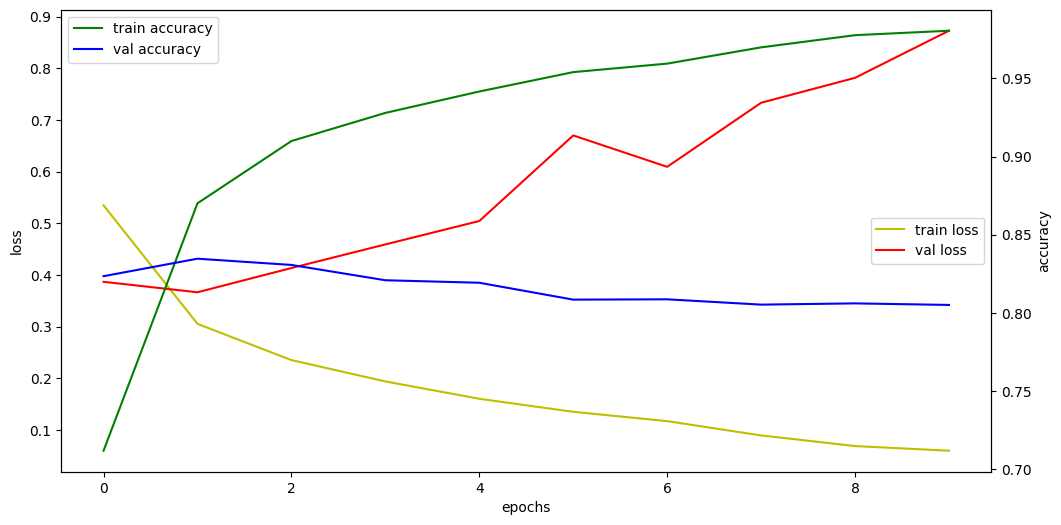

In [21]:
import matplotlib.pyplot as plt
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['acc'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_acc'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

## 11. 모델 평가

In [14]:
# pad_sequences 'post'로 했을 때 : 75%
# pad_sequences 'pre'로 했을 때 : 79%
loss, acc = model.evaluate(X_test, y_test)
print('정확도 :', acc)

782/782 [==============================] - 8s 10ms/step - loss: 1.1259 - acc: 0.7925
정확도 : 0.7924799919128418


In [24]:
# 혼동행렬, recall, precision을 위한 yhat
yhat = (model.predict(X_test) > 0.5).astype(np.int16).reshape(-1)
yhat

782/782 [==============================] - 8s 10ms/step


array([0, 1, 1, ..., 0, 0, 1], dtype=int16)

In [25]:
confusion_matrix(y_test, yhat)

array([[ 9978,  2522],
       [ 2495, 10005]], dtype=int64)

In [26]:
# recall(실제 True인 것 중 True로 예측한 비율) 9542/(2958+9542)
recall_score(y_test, yhat)

0.8004

In [27]:
# precision(True로 예측한 것 중 실제값이 True인 비율) 9542/(2102+9542)
precision_score(y_test, yhat)

0.7986748622974376

## 12. 모델 사용하기

In [28]:
review = """ I should have just finished it after 28 days.
A film that proved "time was poison after all," as the poster says.
The beginning is fun, but as you go back,
you miss all the fun and emotion, and only the disgust remains.@@ㅠㅠ""".lower()
import re
review = re.sub('[^a-zA-z0-9\'\s]', '', review) # ^ : 이 정규표현식이 아닌 것
review = review.split() # 단어 list
review = [1] + [word_to_id.get(word, -1)+3 for word in review]
print(review, len(review))

[1, 13, 144, 28, 43, 1769, 12, 103, 5871, 504, 6, 22, 15, 2085, 58, 16, 5226, 103, 32, 17, 4, 3762, 560, 4, 454, 9, 253, 21, 17, 25, 140, 145, 25, 717, 32, 4, 253, 5, 1426, 5, 64, 4, 6179, 1287] 44


In [29]:
input_data = pad_sequences([review], # 2차원으로 들어와야함
                       padding='pre',
                       truncating='pre',
                       maxlen=MY_LENGTH)
input_data

array([[   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    1,   13,  144,   28,   43, 1769,   12,  103,
        5871,  504,    6,   22,   15, 2085,   58,   16, 5226,  103,   32,
          17,    4, 3762,  560,    4,  454,    9,  253,   21,   17,   25,
         140,  145,   25,  717,   32,    4,  253,    5, 1426,    5,   64,
           4, 6179, 1287]])

In [30]:
result = (model.predict(input_data)>0.5).astype('int8').reshape(-1)
result

1/1 [==============================] - 0s 25ms/step


array([1], dtype=int8)